# TSP

## Versión escalable: heurística Vecino más Cercano + 2-opt

Para más ciudades, el algoritmo exacto (Held-Karp) crece muy rápido. Esta heurística:
1. Construye una ruta inicial con Vecino más Cercano.
2. Mejora la ruta con intercambios 2-opt.

No garantiza óptimo global, pero suele dar rutas muy buenas en tiempos bajos.

Costo inicial (vecino mas cercano): 460.51
Costo mejorado (2-opt):             353.55
Mejora:                             23.2%


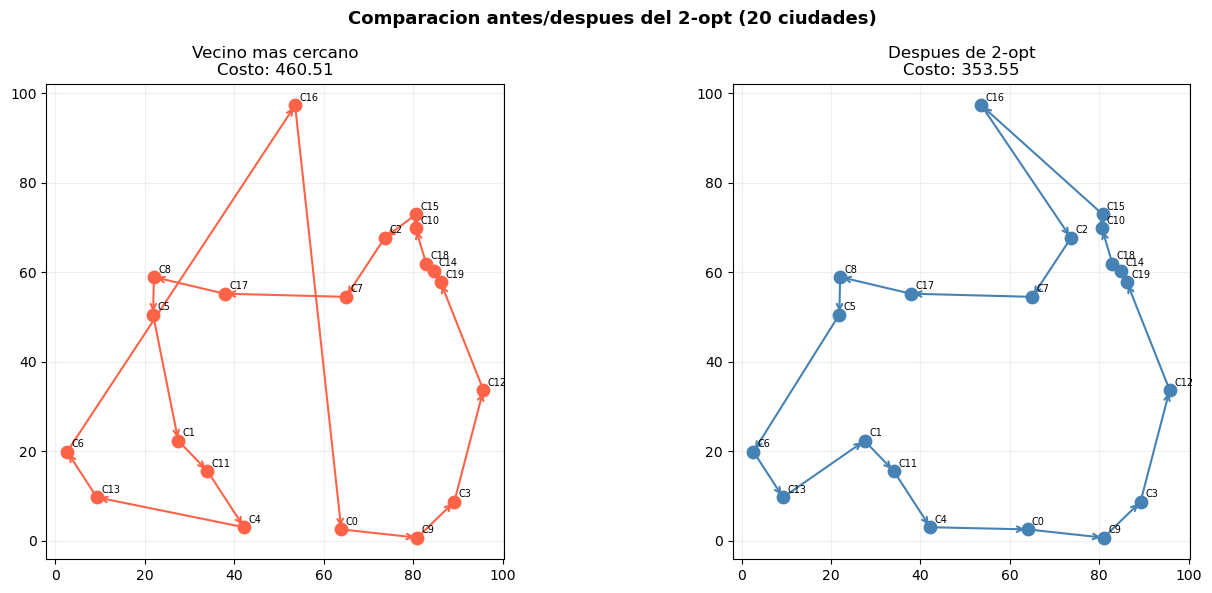

In [22]:
import math
import random
import matplotlib.pyplot as plt


def construir_matriz_distancias(coords):
    n = len(coords)
    dist = [[0.0] * n for _ in range(n)]
    for i in range(n):
        xi, yi = coords[i]
        for j in range(i + 1, n):
            xj, yj = coords[j]
            d = math.hypot(xi - xj, yi - yj)
            dist[i][j] = d
            dist[j][i] = d
    return dist


def costo_ruta(route, dist):
    return sum(dist[route[i]][route[i + 1]] for i in range(len(route) - 1))


def vecino_mas_cercano(dist, start=0):
    n = len(dist)
    no_visitadas = set(range(n))
    no_visitadas.remove(start)
    ruta = [start]
    actual = start
    while no_visitadas:
        siguiente = min(no_visitadas, key=lambda j: dist[actual][j])
        ruta.append(siguiente)
        no_visitadas.remove(siguiente)
        actual = siguiente
    ruta.append(start)
    return ruta


def dos_opt(route, dist):
    """
    2-opt correcto: elimina cruces invirtiendo el segmento entre las dos
    aristas eliminadas. Considera todas las aristas incluida la de retorno.
      - Elimina aristas (route[i], route[i+1]) y (route[j], route[j+1])
      - Invierte route[i+1 : j+1] para reconectar sin cruce
    """
    mejor = route[:]
    mejor_costo = costo_ruta(mejor, dist)
    n = len(mejor) - 1  # numero de ciudades (ruta tiene n+1 elementos)
    improved = True

    while improved:
        improved = False
        for i in range(n - 1):
            for j in range(i + 2, n):
                nueva = mejor[:i+1] + list(reversed(mejor[i+1:j+1])) + mejor[j+1:]
                nuevo_costo = costo_ruta(nueva, dist)
                if nuevo_costo < mejor_costo - 1e-10:
                    mejor = nueva
                    mejor_costo = nuevo_costo
                    improved = True
    return mejor, mejor_costo


def graficar_ruta_heuristica(coords, ruta_antes, ruta_despues, ciudades, dist):
    xs = [p[0] for p in coords]
    ys = [p[1] for p in coords]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, ruta, titulo, color in zip(
        axes,
        [ruta_antes, ruta_despues],
        [f"Vecino mas cercano\nCosto: {costo_ruta(ruta_antes, dist):.2f}",
         f"Despues de 2-opt\nCosto: {costo_ruta(ruta_despues, dist):.2f}"],
        ["tomato", "steelblue"]
    ):
        ax.set_title(titulo, fontsize=12)
        for i in range(len(ruta) - 1):
            a, b = ruta[i], ruta[i+1]
            ax.annotate("", xy=(xs[b], ys[b]), xytext=(xs[a], ys[a]),
                        arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
        ax.scatter(xs, ys, s=80, zorder=3, color=color)
        for i, nombre in enumerate(ciudades):
            ax.text(xs[i] + 1, ys[i] + 1, nombre, fontsize=7)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    plt.suptitle("Comparacion antes/despues del 2-opt (20 ciudades)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Ejemplo con 20 ciudades aleatorias (reproducible) ──────────────
random.seed(42)
n_ciudades = 20
ciudades = [f"C{i}" for i in range(n_ciudades)]
coords = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(n_ciudades)]
dist = construir_matriz_distancias(coords)

ruta_inicial = vecino_mas_cercano(dist, start=0)
costo_inicial = costo_ruta(ruta_inicial, dist)

ruta_mejor, costo_mejor = dos_opt(ruta_inicial, dist)

print(f"Costo inicial (vecino mas cercano): {costo_inicial:.2f}")
print(f"Costo mejorado (2-opt):             {costo_mejor:.2f}")
print(f"Mejora:                             {(1 - costo_mejor/costo_inicial)*100:.1f}%")

graficar_ruta_heuristica(coords, ruta_inicial, ruta_mejor, ciudades, dist)
